---

# Assessment 1 — Introduction to Deep Convolutional Neural Networks

## Deep Learning (COSC 2779 / 2792)

### Name: Sridhar Srinath (**Student ID: S4182099**)

---
## 1. Environment Setup

In [1]:
# Importing necessary libraies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import torch
import random

In [2]:
# Checking if GPU or CPU is used
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
# For Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

---

## 2. Data Accessing and Inspecting

In [4]:
# Defining a function to take a look into the dataset and its folders and subfolders
def peek_directory(root, max_lines=40):
    if not os.path.isdir(root):
        print(f"'{root}' does not exist")
        return
    n = 0
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        print(" " * depth + os.path.basename(dirpath) + "/")
        for f in filenames[:3]:
            print(" " * (depth + 1) + f)
            n += 1
            if n >= max_lines:
                print("...(truncated)")
                return

In [5]:
# Checking if the root directory exists
DATA_ROOT = "./A1_data_2026/data_resized"
peek_directory(DATA_ROOT)

data_resized/
 .DS_Store
 MoveUpward/
  S11/
   Instance5/
    S11_moveUpward_HD_instance5_4.png
    S11_moveUpward_HD_instance5_1.png
    S11_moveUpward_HD_instance5_5.png
   Instance7/
    S11_moveUpward_HD_instance7_2.png
    S11_moveUpward_HD_instance7_3.png
    S11_moveUpward_HD_instance7_5.png
   Instance9/
    S11_moveUpward_HD_instance9_2.png
    S11_moveUpward_HD_instance9_4.png
    S11_moveUpward_HD_instance9_3.png
   Instance4/
    S11_moveUpward_HD_instance4_1.png
    S11_moveUpward_HD_instance4_2.png
    S11_moveUpward_HD_instance4_4.png
   Instance8/
    S11_moveUpward_HD_instance8_5.png
    S11_moveUpward_HD_instance8_3.png
    S11_moveUpward_HD_instance8_2.png
   Instance6/
    S11_moveUpward_HD_instance6_5.png
    S11_moveUpward_HD_instance6_3.png
    S11_moveUpward_HD_instance6_2.png
   Instance1/
    S11_moveUpward_HD_instance1_4.png
    S11_moveUpward_HD_instance1_1.png
    S11_moveUpward_HD_instance1_3.png
   Instance2/
    S11_moveUpward_HD_instance2_2.png
    S11

In [6]:
GESTURE_CLASSES = ["AllClear", "HaveCommand", "Hover", "Land", "LandingDirection",
                   "MoveAhead", "MoveDownward", "MoveToLeft", "MoveToRight",
                   "MoveUpward", "NotClear", "SlowDown", "WaveOff"]

In [7]:
NUM_CLASSES = len(GESTURE_CLASSES)
NUM_FRAMES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 16

In [18]:
import glob
def _find_frame_files(directory, expected_frames=NUM_FRAMES):
    frame_files = glob.glob(os.path.join(directory, "frame_*.*"))
    if not frame_files:
        frame_files = [f for f in glob.glob(os.path.join(directory, "*.*")) if not os.path.basename(f).startswith(".")]
    def frame_num(p):
        m = re.search(r"(\d+)", os.path.basename(p))
        return int(m.group(1)) if m else 0
    return sorted(frame_files, key=frame_num)

In [19]:
def discover_dataset(root_dir, classes=GESTURE_CLASSES, expected_frames=NUM_FRAMES):
    samples = []
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"WARNING: class folder not found: {cls_dir}")
            continue
        for subj in sorted(os.listdir(cls_dir)):
            subj_dir = os.path.join(cls_dir, subj)
            if not os.path.isdir(subj_dir):
                continue
            direct_frames = _find_frame_files(subj_dir, expected_frames)
            if len(direct_frames) == expected_frames:
                samples.append((direct_frames, classes.index(cls), subj))
                continue
            take_dirs = [d for d in sorted(os.listdir(subj_dir)) if os.path.isdir(os.path.join(subj_dir, d))]
            if take_dirs:
                for take in take_dirs:
                    take_dir = os.path.join(subj_dir, take)
                    frames = _find_frame_files(take_dir, expected_frames)
                    if len(frames) == expected_frames:
                        samples.append((frames, classes.index(cls), subj))
                    else:
                        print(f"WARNING: {take_dir} has {len(frames)} frames "
                              f"(expected {expected_frames}) -- skipping.")
            else:
                print(f"WARNING: {subj_dir} has {len(direct_frames)} frames and no sub-folders (expected {expected_frames}) -- skipping. Check your frame-file naming.")
    return samples

In [20]:
def discover_dataset_from_manifest(csv_path, root_dir="", classes=GESTURE_CLASSES):
    df = pd.read_csv(csv_path)
    samples = []
    for inst_id, grp in df.groupby("instance_id"):
        grp = grp.sort_values("frame_index") if "frame_index" in grp.columns else grp
        frame_paths = [os.path.join(root_dir, p) for p in grp["frame_path"].tolist()]
        label = classes.index(grp["class"].iloc[0])
        subject = grp["subject_id"].iloc[0] if "subject_id" in grp.columns else str(inst_id)
        if len(frame_paths) != NUM_FRAMES:
            print(f"WARNING: instance {inst_id} has {len(frame_paths)} frames -- skipping.")
            continue
        samples.append((frame_paths, label, subject))
    return samples
all_samples = discover_dataset(DATA_ROOT)
n_subjects = len(set(s for _, _, s in all_samples))
print(f"Discovered {len(all_samples)} labelled instances across {NUM_CLASSES} classes, "
      f"from {n_subjects} unique subjects.")

Discovered 1059 labelled instances across 13 classes, from 11 unique subjects.


---

## 3. Class distribution and sample instances

In [21]:
all_samples = discover_dataset(DATA_ROOT)
n_subjects = len(set(s for _, _, s in all_samples))
print(f"Discovered {len(all_samples)} labelled instances across {NUM_CLASSES} classes, from {n_subjects} unique subjects.")

Discovered 1059 labelled instances across 13 classes, from 11 unique subjects.


In [22]:
labels_all = [lbl for _, lbl, _ in all_samples]
unique, counts = np.unique(labels_all, return_counts=True)

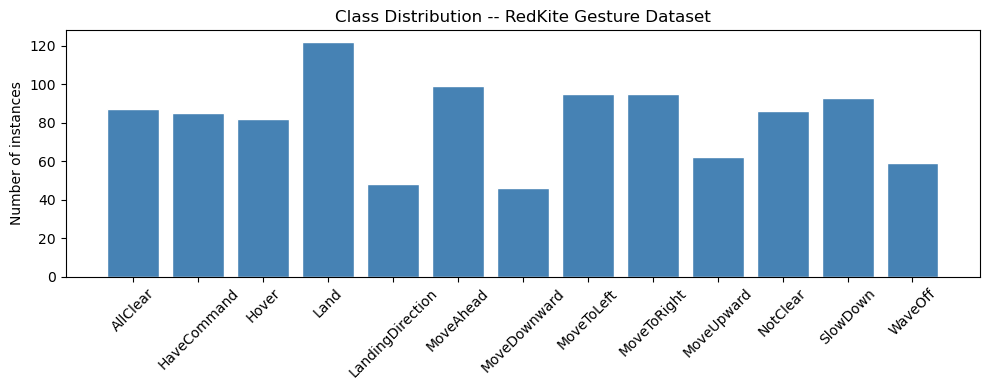

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([GESTURE_CLASSES[u] for u in unique], counts, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution -- RedKite Gesture Dataset')
ax.set_ylabel('Number of instances')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [25]:
for u, c in zip(unique, counts):
    print(f'  {GESTURE_CLASSES[u]:<16} {c}')

  AllClear         87
  HaveCommand      85
  Hover            82
  Land             122
  LandingDirection 48
  MoveAhead        99
  MoveDownward     46
  MoveToLeft       95
  MoveToRight      95
  MoveUpward       62
  NotClear         86
  SlowDown         93
  WaveOff          59


In [26]:
def show_instance(frame_paths, title=""):
    fig, axes = plt.subplots(1, len(frame_paths), figsize=(12, 3))
    for ax, p in zip(axes, frame_paths):
        ax.imshow(Image.open(p).convert("RGB"))
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

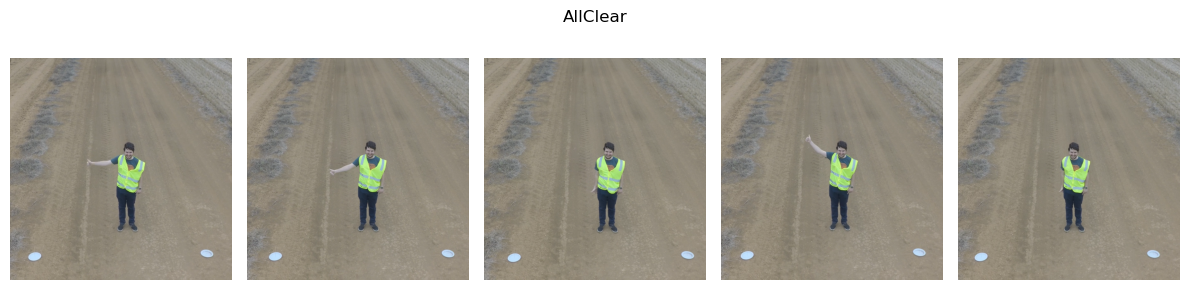

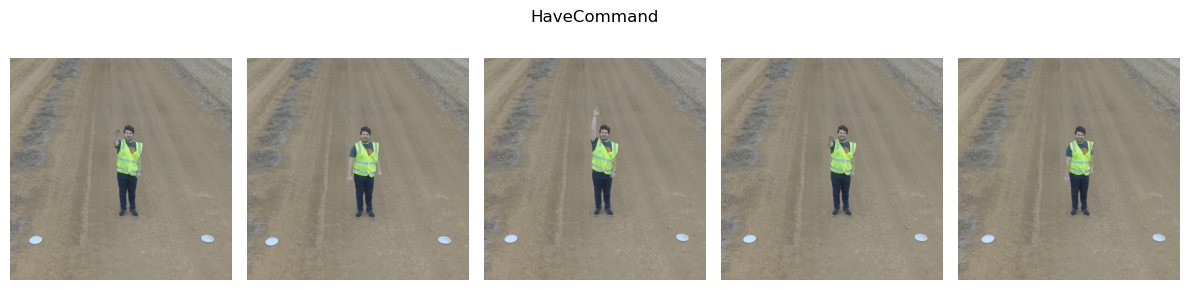

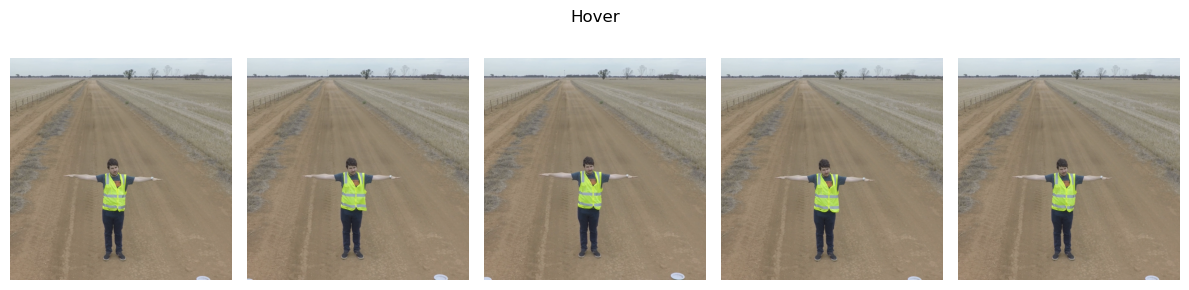

In [29]:
from PIL import Image
sample_by_class = {}
for frames, lbl, _ in all_samples:
    sample_by_class.setdefault(lbl, frames)
for lbl, frames in list(sample_by_class.items())[:3]:
    show_instance(frames, title=GESTURE_CLASSES[lbl])

---